In [3]:
import numpy as np
import matplotlib.pyplot as plt


TASK 3.1: Batch Mode Approximation (Clean Data)

--- Target: sin(2x) ---
Threshold < 0.1 reached with 6 units (Error: 0.03366)
Threshold < 0.01 reached with 12 units (Error: 0.00962)
Threshold < 0.001 reached with 54 units (Error: 0.00099)

--- Target: square(2x) ---


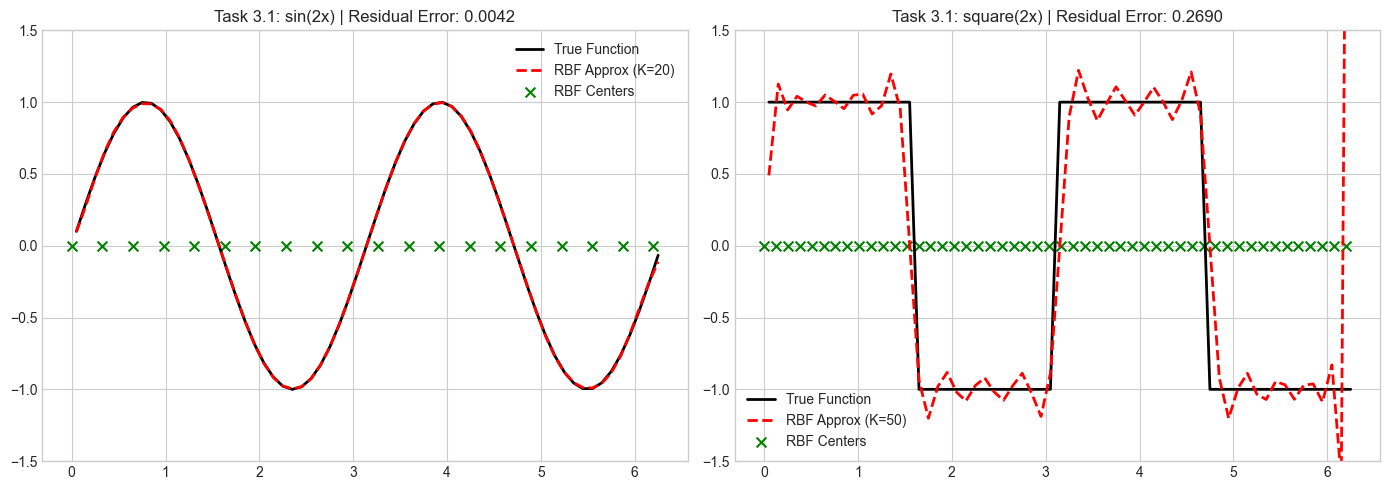


TASK 3.2: Regression with Noise (Batch vs Delta Rule)


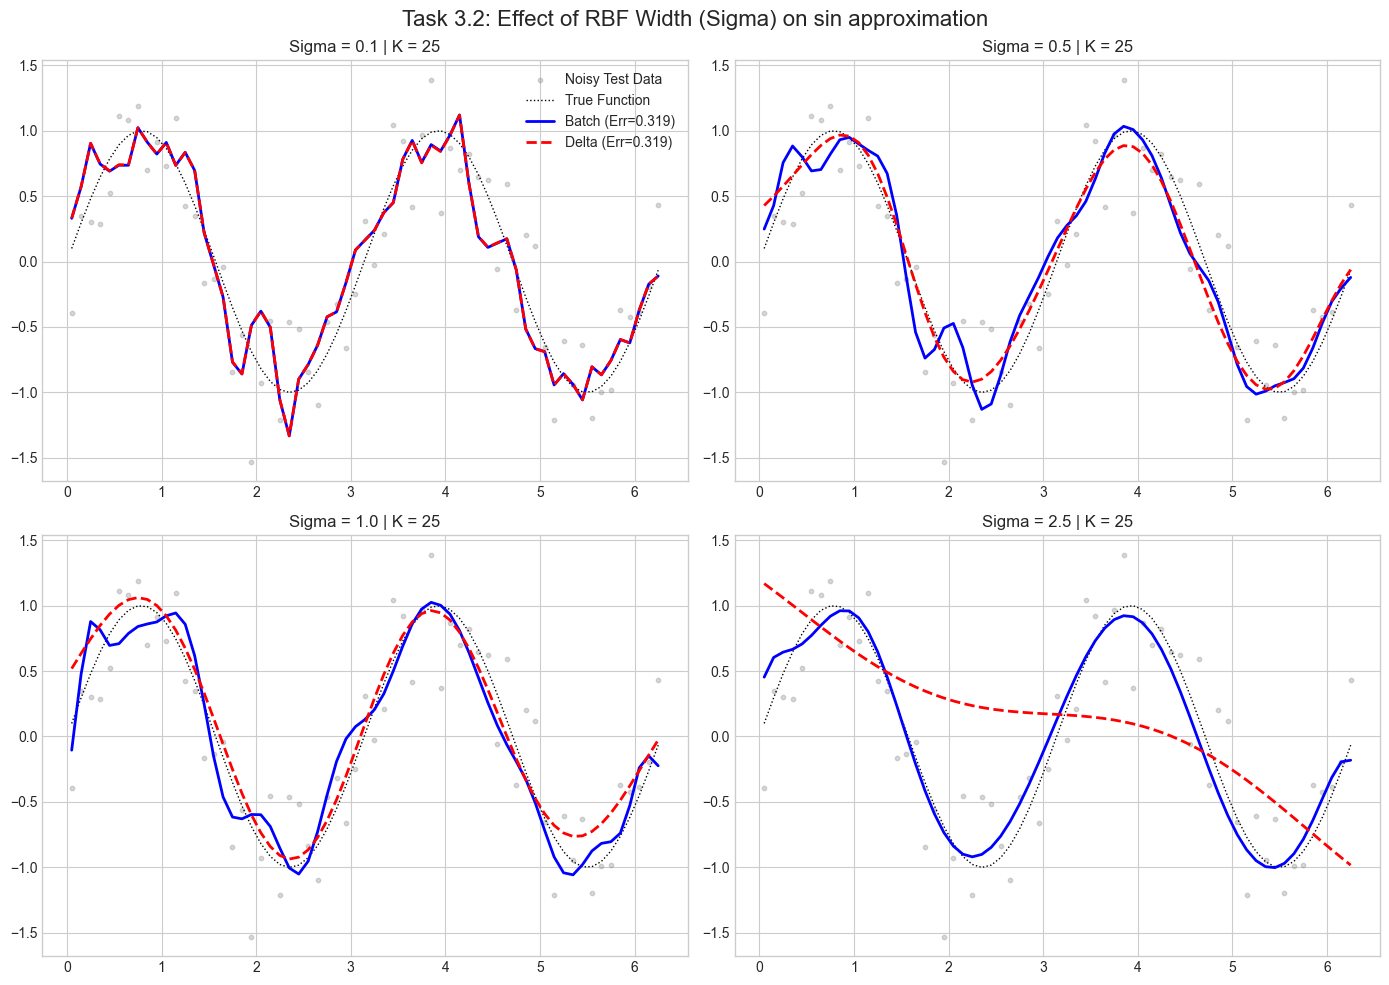


Visualizing Delta Rule Convergence...


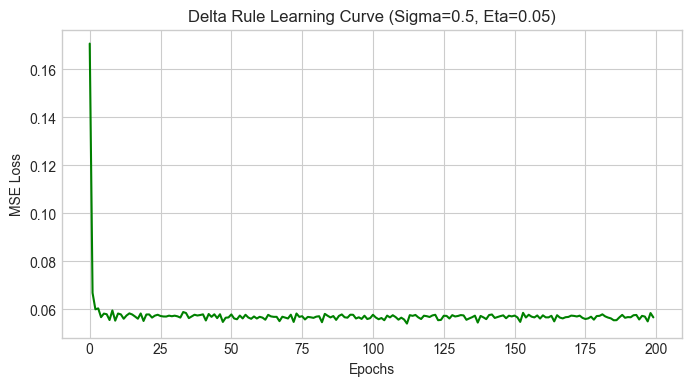

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

plt.style.use('seaborn-v0_8-whitegrid')


def generate_data(func_type='sin', noise_var=0.0):
    """
    Generates training and testing data for the lab.
    """
    X_train = np.arange(0, 2 * np.pi, 0.1).reshape(-1, 1)
    X_test = np.arange(0.05, 2 * np.pi, 0.1).reshape(-1, 1)
    
    if func_type == 'sin':

        y_train = np.sin(2 * X_train)
        y_test = np.sin(2 * X_test)
    elif func_type == 'square':
        y_train = np.sign(np.sin(2 * X_train))
        y_test = np.sign(np.sin(2 * X_test))
        y_train[y_train == 0] = 1
        y_test[y_test == 0] = 1
        
    if noise_var > 0:
        noise_tr = np.random.normal(0, np.sqrt(noise_var), y_train.shape)
        noise_te = np.random.normal(0, np.sqrt(noise_var), y_test.shape)
        y_train += noise_tr
        y_test += noise_te
        
    return X_train, y_train, X_test, y_test

def place_rbf_centers(X, K):
    """
    Places RBF units 'by hand' (evenly spaced) covering the input domain.
    
    """
    start = np.min(X)
    end = np.max(X)
    centers = np.linspace(start, end, K).reshape(-1, 1)
    return centers

def gaussian_rbf_activations(X, centers, sigma):
    """
    Computes the Design Matrix (Phi).
    phi_i(x) = exp( -(x - mu)^2 / (2*sigma^2) ) [cite: 45]
    """
    dist_sq = cdist(X, centers, metric='sqeuclidean')
    Phi = np.exp(-dist_sq / (2 * sigma**2))
    return Phi

def calculate_absolute_residual_error(y_true, y_pred):
    """
    Average absolute difference between network output and target.
    error = mean(|y_true - y_pred|) 
    """
    return np.mean(np.abs(y_true - y_pred))


def train_batch_rbf(Phi, y):
    """
    Batch learning using Least Squares (Normal Equations).
    w = (Phi^T * Phi)^-1 * Phi^T * f 
    Using pinv for stability.
    """
    w = np.linalg.pinv(Phi) @ y
    return w

def train_delta_rbf(X, y, centers, sigma, learning_rate=0.01, epochs=100):
    """
    Sequential (On-line) learning using the Delta Rule.
    Delta w = eta * error * phi(x) [cite: 108]
    """
    N, _ = X.shape
    K = centers.shape[0]
    w = np.random.randn(K, 1) * 0.1 # Small random init
    
    loss_history = []
    
    Phi_full = gaussian_rbf_activations(X, centers, sigma)
    
    for epoch in range(epochs):
        perm = np.random.permutation(N)
        X_shuffled = X[perm]
        y_shuffled = y[perm]
        Phi_shuffled = Phi_full[perm]
        
        total_error = 0
        
        for i in range(N):
            phi_x = Phi_shuffled[i:i+1] # Shape (1, K)
            target = y_shuffled[i:i+1]
            
            pred = phi_x @ w
            error = target - pred
            

            update = learning_rate * error * phi_x.T
            w += update
            
            total_error += 0.5 * (error.item() ** 2)
            
        loss_history.append(total_error / N)
        
    return w, loss_history


def run_task_3_1_clean_approximation():
    print("\n" + "="*60)
    print("TASK 3.1: Batch Mode Approximation (Clean Data)")
    print("="*60)
    
    functions = ['sin', 'square']
    error_thresholds = [0.1, 0.01, 0.001]
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    for i, func in enumerate(functions):
        print(f"\n--- Target: {func}(2x) ---")
        X_tr, y_tr, X_te, y_te = generate_data(func, noise_var=0.0)
        
        found_thresholds = []
        best_model = None
        for K in range(2, 65):

            centers = place_rbf_centers(X_tr, K)
            
            step_size = (np.max(X_tr) - np.min(X_tr)) / (K - 1)
            sigma = step_size  
            if func == 'square': sigma = 0.5 
            

            Phi_tr = gaussian_rbf_activations(X_tr, centers, sigma)
            w = train_batch_rbf(Phi_tr, y_tr)
            

            Phi_te = gaussian_rbf_activations(X_te, centers, sigma)
            y_pred = Phi_te @ w
            res_err = calculate_absolute_residual_error(y_te, y_pred)
            

            for thresh in error_thresholds:
                if res_err < thresh and thresh not in found_thresholds:
                    print(f"Threshold < {thresh} reached with {K} units (Error: {res_err:.5f})")
                    found_thresholds.append(thresh)
            

            if K == 20 or (func=='square' and K==50): 
                best_model = (centers, w, sigma, y_pred, K)
        

        centers, w, sigma, y_pred, K = best_model
        ax = axes[i]
        ax.plot(X_te, y_te, 'k-', linewidth=2, label='True Function')
        ax.plot(X_te, y_pred, 'r--', linewidth=2, label=f'RBF Approx (K={K})')
        ax.scatter(centers, np.zeros_like(centers), marker='x', color='green', s=50, label='RBF Centers')
        ax.set_title(f"Task 3.1: {func}(2x) | Residual Error: {calculate_absolute_residual_error(y_te, y_pred):.4f}")
        ax.legend()
        ax.set_ylim(-1.5, 1.5)

    plt.tight_layout()
    plt.show()

def run_task_3_2_noise_comparison():
    print("\n" + "="*60)
    print("TASK 3.2: Regression with Noise (Batch vs Delta Rule)")
    print("="*60)
    
    func = 'sin'
    noise_var = 0.1
    X_tr, y_tr, X_te, y_te = generate_data(func, noise_var=noise_var)
    

    K = 25 
    centers = place_rbf_centers(X_tr, K)
    
    sigmas = [0.1, 0.5, 1.0, 2.5] 
    
    eta = 0.05 
    epochs = 200 
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    for i, sigma in enumerate(sigmas):
        Phi_tr = gaussian_rbf_activations(X_tr, centers, sigma)
        Phi_te = gaussian_rbf_activations(X_te, centers, sigma)
        
        w_batch = train_batch_rbf(Phi_tr, y_tr)
        pred_batch = Phi_te @ w_batch
        err_batch = calculate_absolute_residual_error(y_te, pred_batch)
        
        w_delta, loss_hist = train_delta_rbf(X_tr, y_tr, centers, sigma, eta, epochs)
        pred_delta = gaussian_rbf_activations(X_te, centers, sigma) @ w_delta
        err_delta = calculate_absolute_residual_error(y_te, pred_delta)
        
        ax = axes[i]
        ax.scatter(X_te, y_te, c='gray', alpha=0.3, s=10, label='Noisy Test Data')
        ax.plot(X_te, np.sin(2*X_te), 'k:', linewidth=1, label='True Function')
        ax.plot(X_te, pred_batch, 'b-', linewidth=2, label=f'Batch (Err={err_batch:.3f})')
        ax.plot(X_te, pred_delta, 'r--', linewidth=2, label=f'Delta (Err={err_delta:.3f})')
        
        ax.set_title(f"Sigma = {sigma} | K = {K}")
        if i == 0: ax.legend()
        
    plt.suptitle(f"Task 3.2: Effect of RBF Width (Sigma) on {func} approximation", fontsize=16)
    plt.tight_layout()
    plt.show()

    print("\nVisualizing Delta Rule Convergence...")
    sigma_opt = 0.5
    _, loss_history = train_delta_rbf(X_tr, y_tr, centers, sigma_opt, eta, epochs)
    
    plt.figure(figsize=(8, 4))
    plt.plot(loss_history, 'g-')
    plt.title(f"Delta Rule Learning Curve (Sigma={sigma_opt}, Eta={eta})")
    plt.xlabel("Epochs")
    plt.ylabel("MSE Loss")
    plt.grid(True)
    plt.show()

if __name__ == "__main__":
    run_task_3_1_clean_approximation()
    
    run_task_3_2_noise_comparison()

TASK 3.1: Batch Mode Approximation (Clean Data)

Processing Target: sin(2x)
  -> Threshold < 0.1 met with K=7 units (Error: 0.03665)


<Figure size 800x300 with 0 Axes>

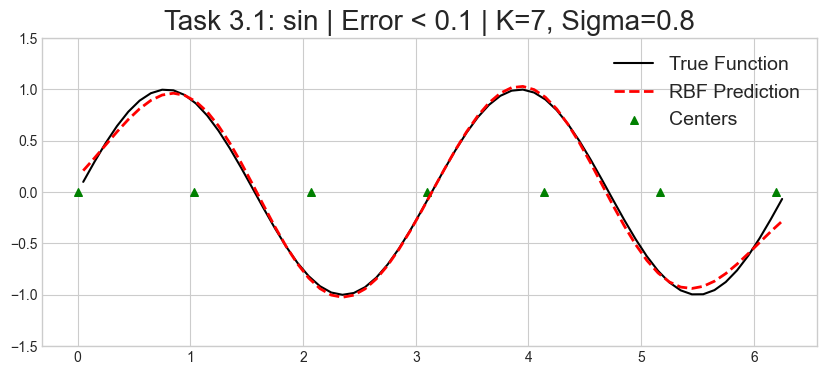

  -> Threshold < 0.01 met with K=10 units (Error: 0.00786)


<Figure size 800x300 with 0 Axes>

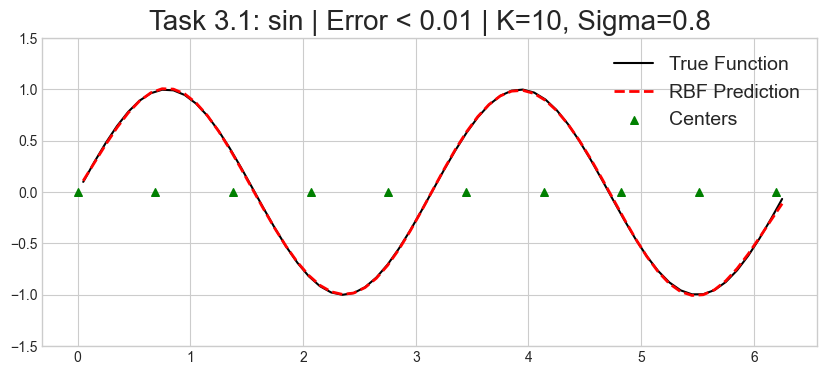

  -> Threshold < 0.001 met with K=14 units (Error: 0.00048)


<Figure size 800x300 with 0 Axes>

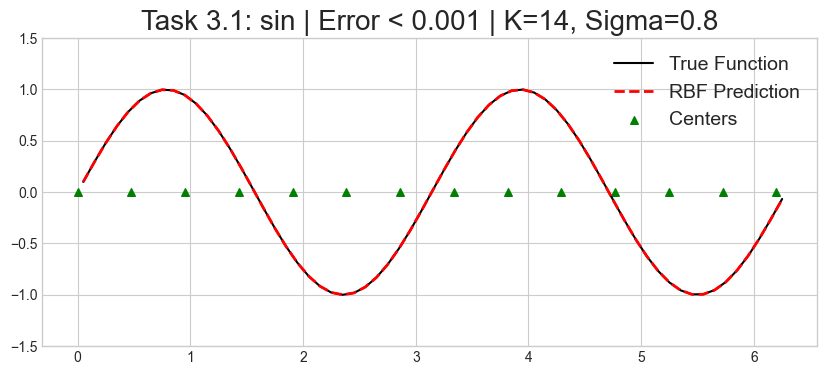

  -> Best Result for sin: K=22, Error=0.00000


<Figure size 1000x500 with 0 Axes>

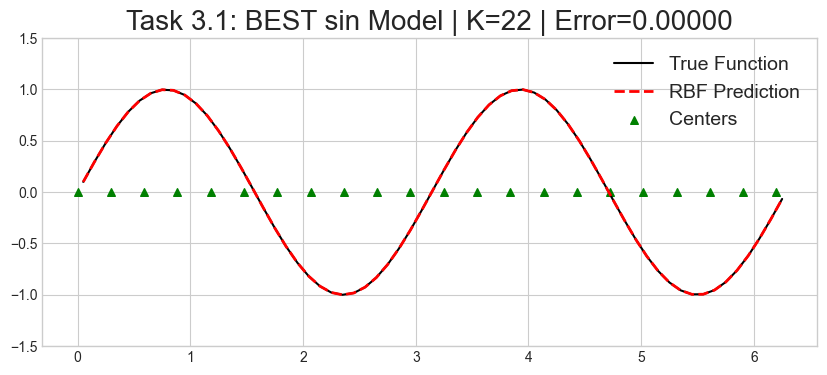


Processing Target: square(2x)
  -> Threshold < 0.1 met with K=38 units (Error: 0.09989)


<Figure size 800x300 with 0 Axes>

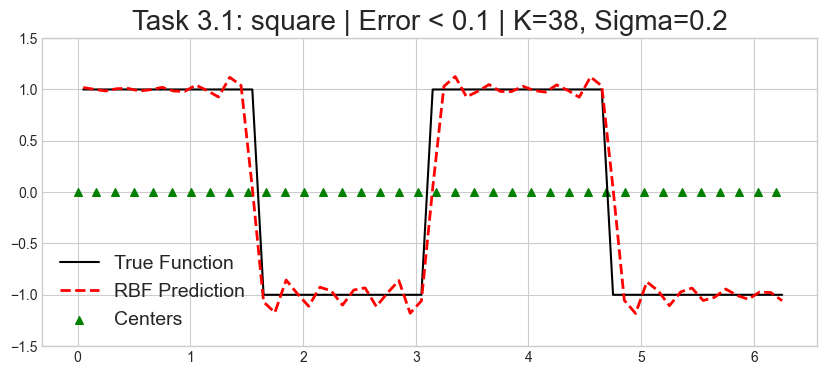

  -> Best Result for square: K=49, Error=0.09869


<Figure size 1000x500 with 0 Axes>

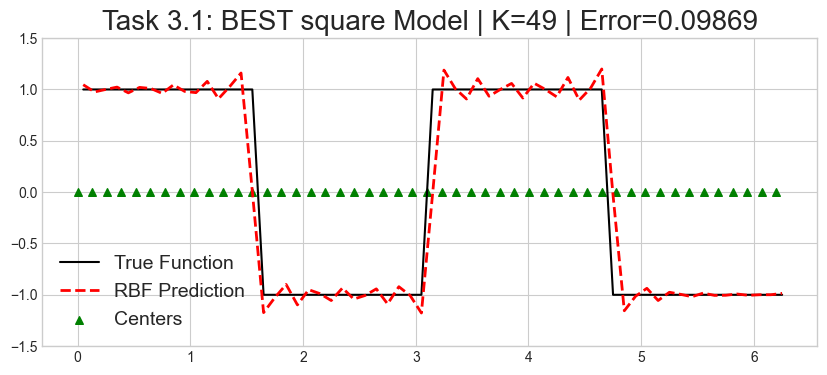


TASK 3.2: Regression with Noise (Batch vs Delta)
Comparison: Batch vs Delta Rule (K=20)


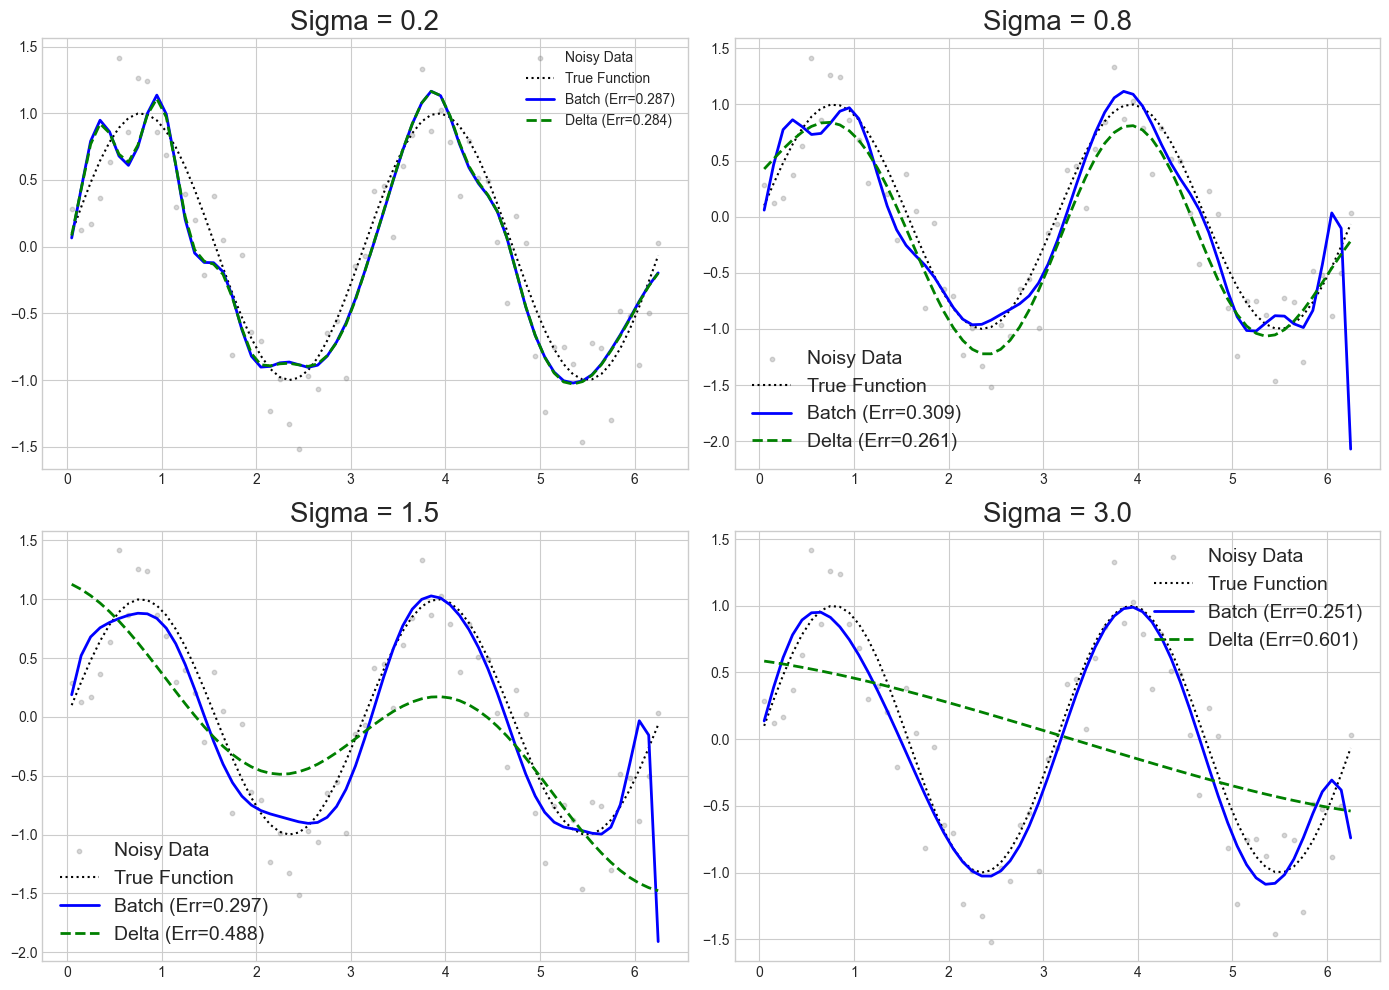

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist

plt.style.use('seaborn-v0_8-whitegrid')


class RBFNetwork:
    def __init__(self, k_units, sigma=None, centers=None):
        self.K = k_units
        self.sigma = sigma
        self.centers = centers
        self.weights = None

    def place_centers_equidistant(self, X):
        """Places centers evenly across the input range."""
        start = np.min(X)
        end = np.max(X)
        self.centers = np.linspace(start, end, self.K).reshape(-1, 1)
        
        if self.sigma is None:
            self.sigma = (end - start) / self.K

    def _compute_phi(self, X):
        """
        Computes the design matrix Phi using Gaussian activation.
        """
        if self.centers is None:
            raise ValueError("Centers not initialized.")
        
        dist_sq = cdist(X, self.centers, metric='sqeuclidean')
        Phi = np.exp(-dist_sq / (2 * self.sigma**2))
        return Phi

    def train_batch(self, X, y):
        """
        Trains weights using Batch Least Squares.
        """
        if self.centers is None:
            self.place_centers_equidistant(X)
            
        Phi = self._compute_phi(X)
        # Solve linear system
        self.weights = np.linalg.pinv(Phi) @ y

    def train_delta(self, X, y, eta=0.1, epochs=100):
        """
        Trains weights using the Delta Rule (On-line).
        """
        if self.centers is None:
            self.place_centers_equidistant(X)
            
        N = X.shape[0]
        self.weights = np.random.randn(self.K, 1) * 0.1
        loss_history = []
        
       
        Phi_all = self._compute_phi(X)
        
        for epoch in range(epochs):            
            perm = np.random.permutation(N)
            total_error = 0
            
            for i in perm:
                phi_x = Phi_all[i:i+1] 
                target = y[i:i+1]
                
                pred = phi_x @ self.weights
                error = target - pred
                

                self.weights += eta * error * phi_x.T
                total_error += 0.5 * error**2
                
            loss_history.append(total_error.item() / N)
            
        return loss_history

    def predict(self, X):

        Phi = self._compute_phi(X)
        return Phi @ self.weights



def generate_data(func_type='sin', noise_var=0.0):
    """
    Generates training [0, 2pi] and testing [0.05, 2pi] data.
    """

    X_train = np.arange(0, 2 * np.pi, 0.1).reshape(-1, 1)

    X_test = np.arange(0.05, 2 * np.pi, 0.1).reshape(-1, 1)
    
    if func_type == 'sin':
        y_train = np.sin(2 * X_train)
        y_test = np.sin(2 * X_test)
    elif func_type == 'square':
        y_train = np.sign(np.sin(2 * X_train))
        y_test = np.sign(np.sin(2 * X_test))
        y_train[y_train == 0] = 1
        y_test[y_test == 0] = 1

    if noise_var > 0:
        noise_tr = np.random.normal(0, np.sqrt(noise_var), y_train.shape)
        noise_te = np.random.normal(0, np.sqrt(noise_var), y_test.shape)
        y_train += noise_tr
        y_test += noise_te
        
    return X_train, y_train, X_test, y_test

def calc_residual(y_true, y_pred):

    return np.mean(np.abs(y_true - y_pred))

def plot_result(X, y_true, y_pred, centers, title, ax=None):
    if ax is None:
        plt.figure(figsize=(10, 4))
        ax = plt.gca()
        
    ax.plot(X, y_true, 'k-', linewidth=1.5, label='True Function')
    ax.plot(X, y_pred, 'r--', linewidth=2, label='RBF Prediction')
    if centers is not None:
        ax.scatter(centers, np.zeros_like(centers), marker='^', color='green', s=30, label='Centers')
        
    ax.set_title(title, fontsize=20)
    
    ax.legend(fontsize=14)
    
    ax.set_ylim(-1.5, 1.5)
    

def run_task_3_1():
    print("="*60)
    print("TASK 3.1: Batch Mode Approximation (Clean Data)")
    print("="*60)
    
    thresholds = [0.1, 0.01, 0.001]
    functions = ['sin', 'square']
    
    for func in functions:
        print(f"\nProcessing Target: {func}(2x)")
        X_tr, y_tr, X_te, y_te = generate_data(func, noise_var=0.0)
        
        met_thresholds = set()
        best_model_info = None
        min_error = float('inf')
        
        for K in range(2, 400):
            sigma = 0.8 if func == 'sin' else 0.2 
            rbf = RBFNetwork(k_units=K, sigma=sigma)
            
            rbf.train_batch(X_tr, y_tr)
            
            y_pred = rbf.predict(X_te)
            error = calc_residual(y_te, y_pred)
            
            if error < min_error:
                min_error = error
                best_model_info = (rbf, y_pred, K, error)
            
            for thresh in thresholds:
                if error < thresh and thresh not in met_thresholds:
                    print(f"  -> Threshold < {thresh} met with K={K} units (Error: {error:.5f})")
                    met_thresholds.add(thresh)
                    
                    plt.figure(figsize=(8, 3))
                    plot_result(X_te, y_te, y_pred, rbf.centers, 
                                f"Task 3.1: {func} | Error < {thresh} | K={K}, Sigma={sigma}")
                    plt.show()

        best_rbf, best_pred, best_K, best_err = best_model_info
        print(f"  -> Best Result for {func}: K={best_K}, Error={best_err:.5f}")
        plt.figure(figsize=(10, 5))
        plot_result(X_te, y_te, best_pred, best_rbf.centers, 
                    f"Task 3.1: BEST {func} Model | K={best_K} | Error={best_err:.5f}")
        plt.show()


def run_task_3_2():
    print("\n" + "="*60)
    print("TASK 3.2: Regression with Noise (Batch vs Delta)")
    print("="*60)
    
    func = 'sin'
    noise_var = 0.1 
    X_tr, y_tr, X_te, y_te = generate_data(func, noise_var=noise_var)
    
    K = 20 
    sigmas = [0.2, 0.8, 1.5, 3.0] 
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()
    
    print(f"Comparison: Batch vs Delta Rule (K={K})")
    
    for i, sigma in enumerate(sigmas):
        rbf_batch = RBFNetwork(K, sigma=sigma)
        rbf_batch.train_batch(X_tr, y_tr)
        pred_batch = rbf_batch.predict(X_te)
        err_batch = calc_residual(y_te, pred_batch)
        
        rbf_delta = RBFNetwork(K, sigma=sigma)
        loss_hist = rbf_delta.train_delta(X_tr, y_tr, eta=0.05, epochs=100)
        pred_delta = rbf_delta.predict(X_te)
        err_delta = calc_residual(y_te, pred_delta)
        
        ax = axes[i]
        ax.scatter(X_te, y_te, c='gray', alpha=0.3, s=10, label='Noisy Data')
        ax.plot(X_te, np.sin(2*X_te), 'k:', label='True Function')
        ax.plot(X_te, pred_batch, 'b-', linewidth=2, label=f'Batch (Err={err_batch:.3f})')
        ax.plot(X_te, pred_delta, 'g--', linewidth=2, label=f'Delta (Err={err_delta:.3f})')
    
        ax.legend(fontsize=14)
        ax.set_title(f"Sigma = {sigma}", fontsize=20)
        if i == 0: ax.legend()
            
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    run_task_3_1()
    run_task_3_2()


TASK 3.2: Regression with Noise (Varying K and Sigma)

Running experiments for K = 5 units...


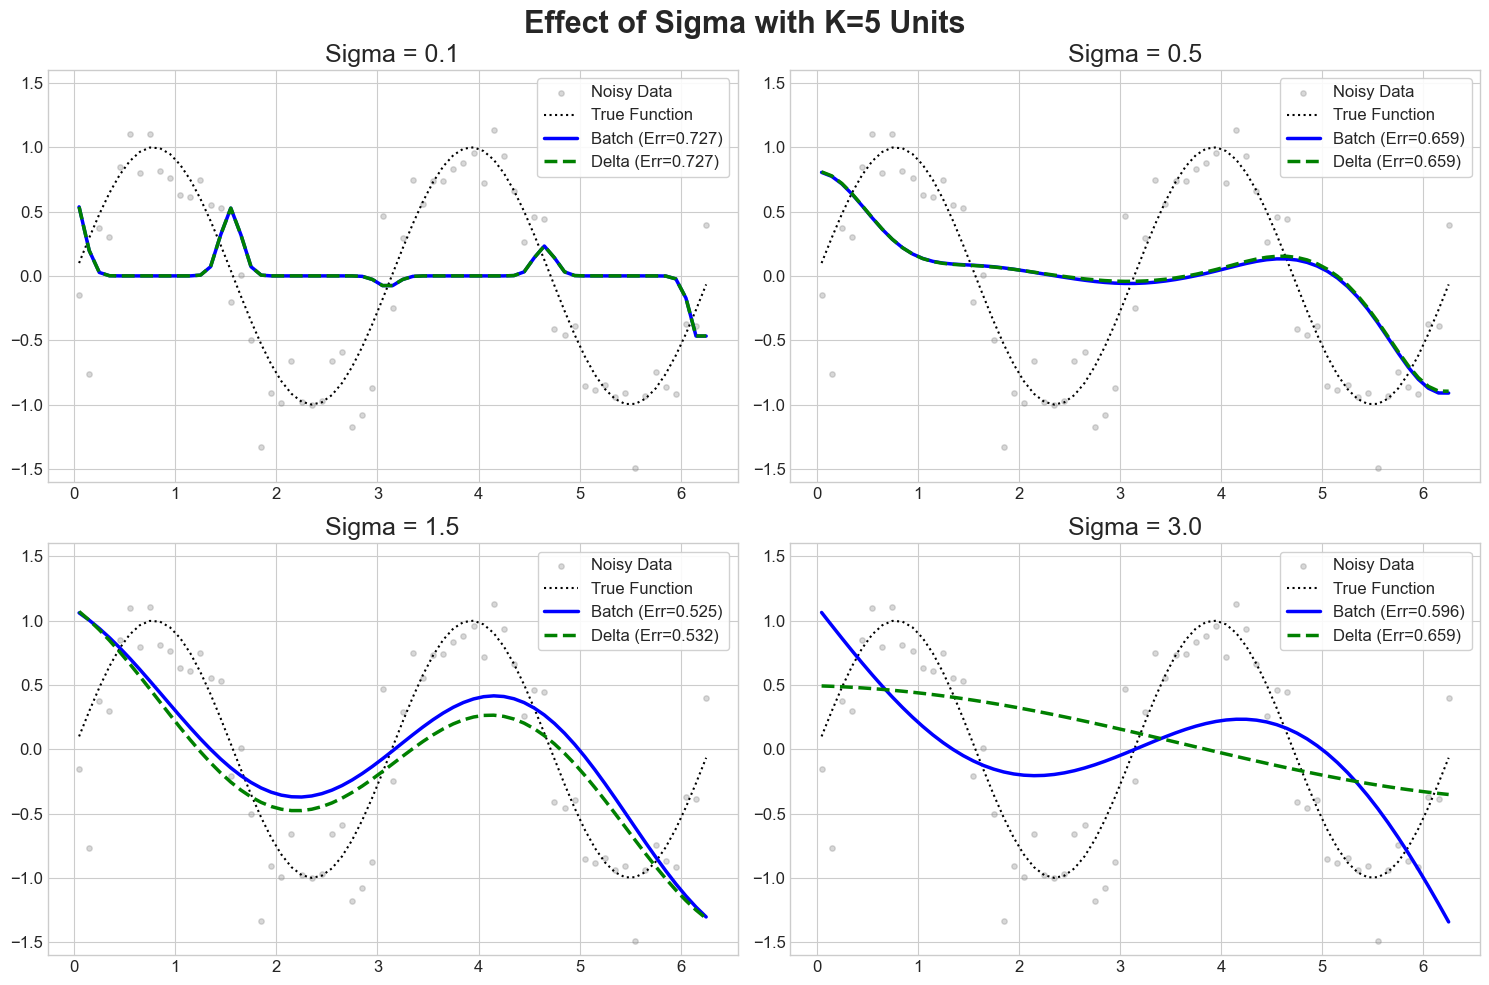


Running experiments for K = 20 units...


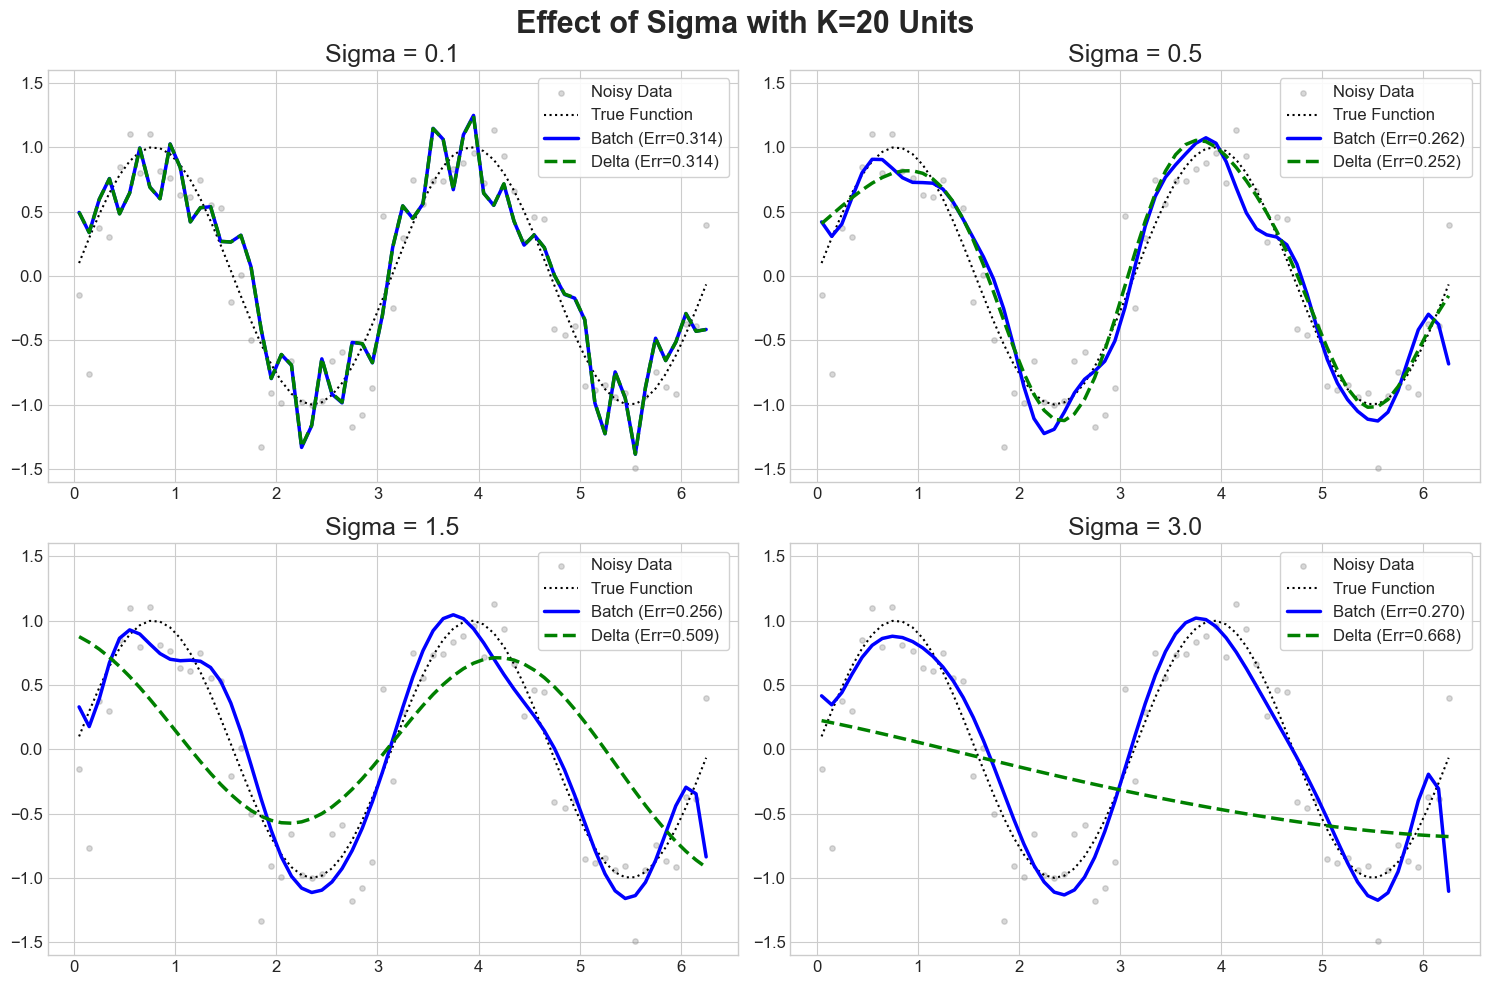


Running experiments for K = 60 units...


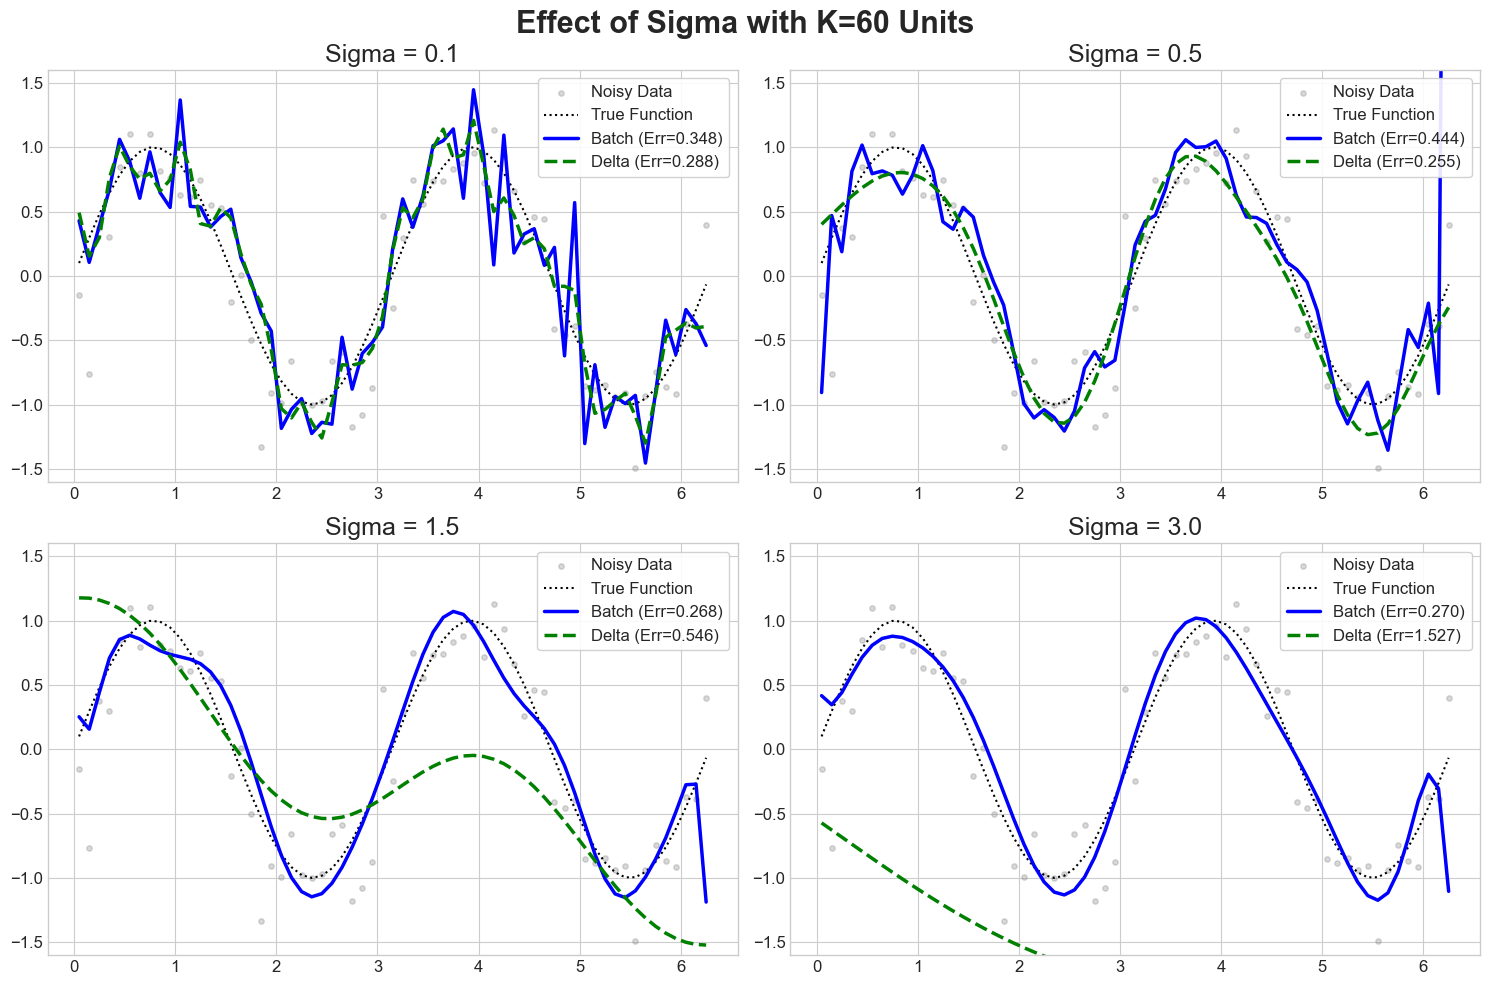

In [ ]:
def run_task_3_2():
    print("\n" + "="*60)
    print("TASK 3.2: Regression with Noise (Varying K and Sigma)")
    print("="*60)
    
    func = 'sin'
    noise_var = 0.1 
    X_tr, y_tr, X_te, y_te = generate_data(func, noise_var=noise_var)
    
    Ks = [5, 20, 60] 
    
    sigmas = [0.1, 0.5, 1.5, 3.0] 
    
    eta = 0.05 
    epochs = 100 

    for K in Ks:
        print(f"\nRunning experiments for K = {K} units...")
        
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        axes = axes.flatten()
        fig.suptitle(f'Effect of Sigma with K={K} Units', fontsize=22, fontweight='bold')
        
        for i, sigma in enumerate(sigmas):
            rbf_batch = RBFNetwork(K, sigma=sigma)
            rbf_batch.train_batch(X_tr, y_tr)
            pred_batch = rbf_batch.predict(X_te)
            err_batch = calc_residual(y_te, pred_batch)
            
            rbf_delta = RBFNetwork(K, sigma=sigma)
            loss_hist = rbf_delta.train_delta(X_tr, y_tr, eta=eta, epochs=epochs)
            pred_delta = rbf_delta.predict(X_te)
            err_delta = calc_residual(y_te, pred_delta)
            
            ax = axes[i]
            
            ax.scatter(X_te, y_te, c='gray', alpha=0.3, s=15, label='Noisy Data')
            ax.plot(X_te, np.sin(2*X_te), 'k:', linewidth=1.5, label='True Function')
            
            ax.plot(X_te, pred_batch, 'b-', linewidth=2.5, label=f'Batch (Err={err_batch:.3f})')
            
            ax.plot(X_te, pred_delta, 'g--', linewidth=2.5, label=f'Delta (Err={err_delta:.3f})')
            
            ax.set_title(f"Sigma = {sigma}", fontsize=18)
            ax.set_ylim(-1.6, 1.6)
            ax.tick_params(axis='both', which='major', labelsize=12)
            
            ax.legend(fontsize=12, loc='upper right', frameon=True, framealpha=0.9)

        plt.tight_layout()
        plt.subplots_adjust(top=0.92)
        plt.show()

if __name__ == "__main__":
    run_task_3_2()


TASK 3.2: Square(2x) Regression with Noise

Running experiments for K = 10 units...


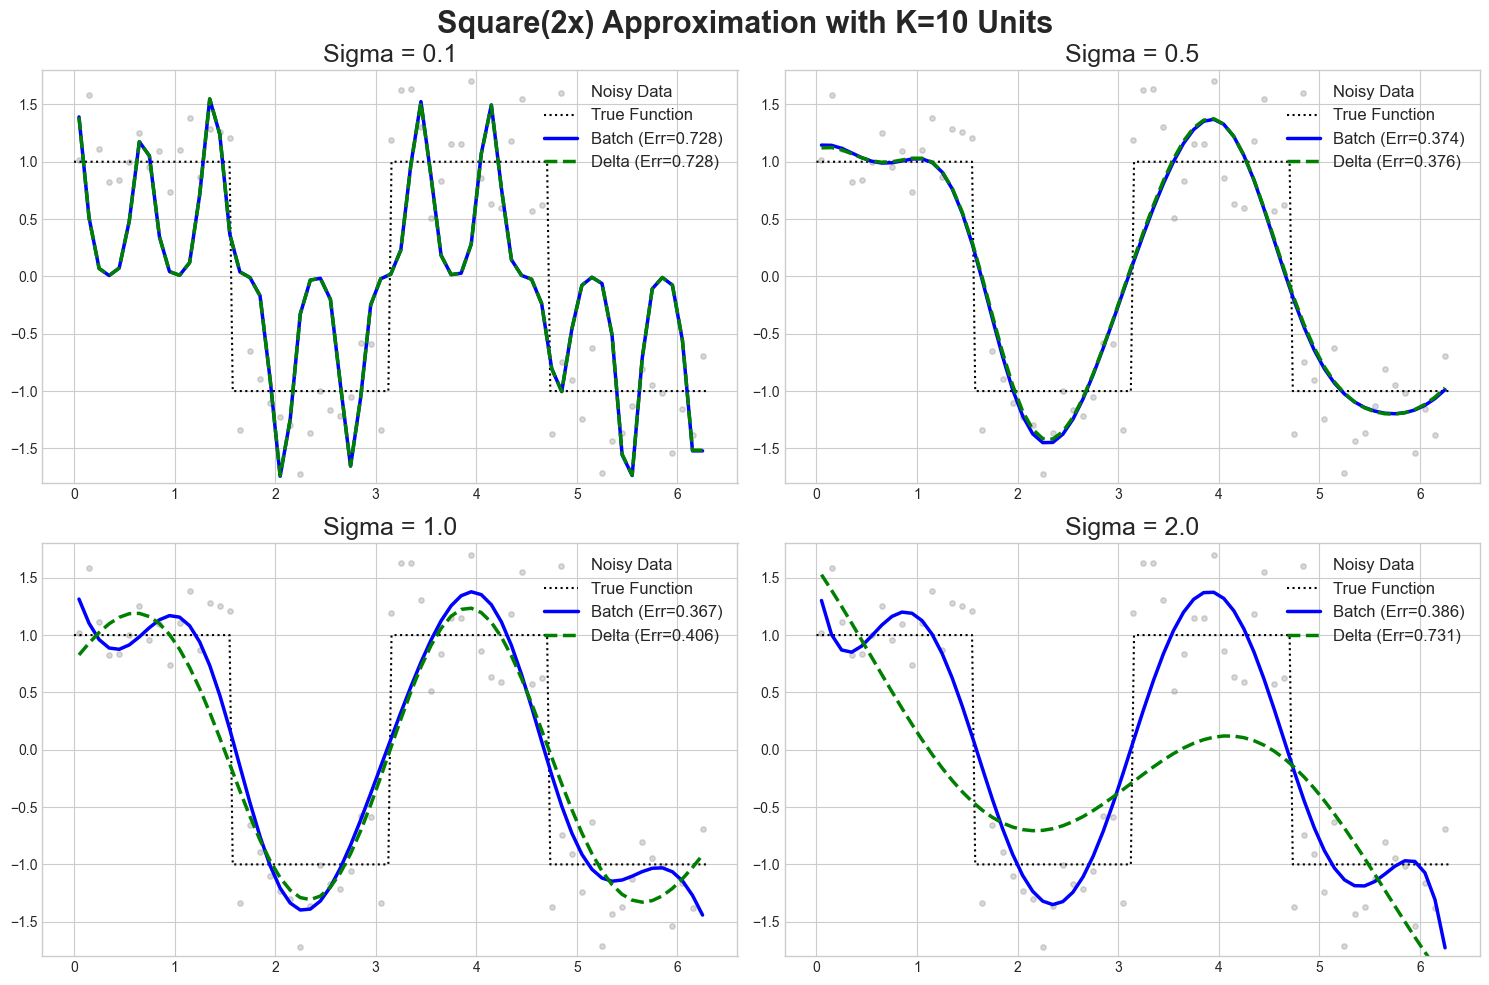


Running experiments for K = 30 units...


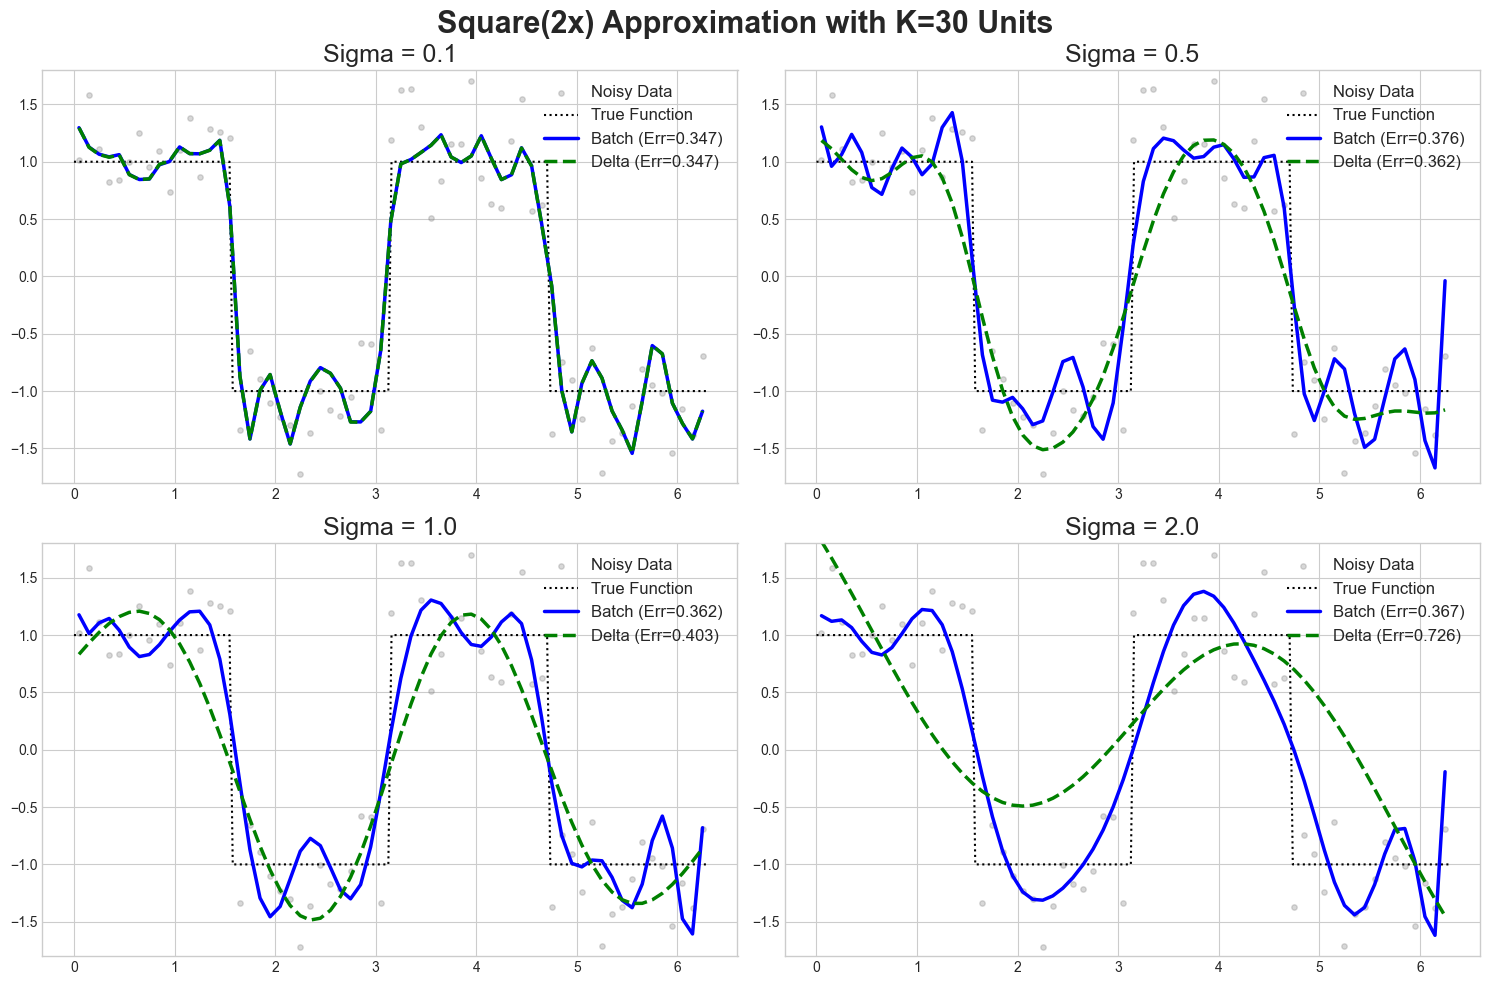


Running experiments for K = 60 units...


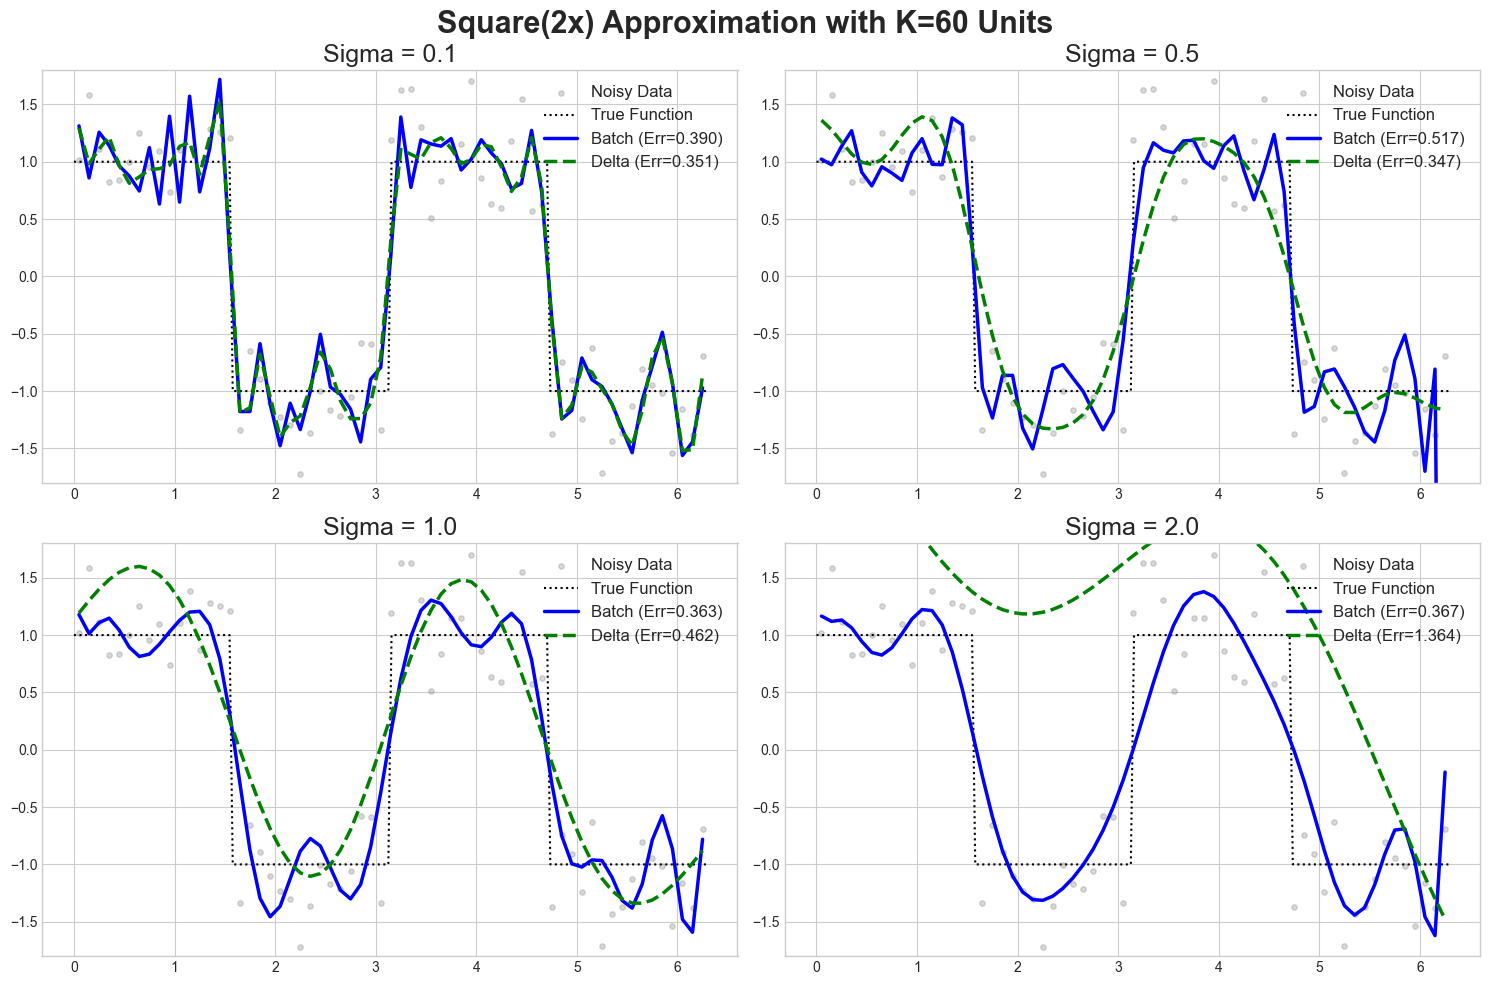

In [ ]:
def run_task_3_2_square():
    print("\n" + "="*60)
    print("TASK 3.2: Square(2x) Regression with Noise")
    print("="*60)
    
    noise_var = 0.1 
    X_tr, y_tr, X_te, y_te = generate_data('square', noise_var=noise_var)
    
    Ks = [10, 30, 60] 
    sigmas = [0.1, 0.5, 1.0, 2.0] 
    eta = 0.05 
    epochs = 150 

    for K in Ks:
        print(f"\nRunning experiments for K = {K} units...")
        
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        axes = axes.flatten()
        fig.suptitle(f'Square(2x) Approximation with K={K} Units', fontsize=22, fontweight='bold')
        
        for i, sigma in enumerate(sigmas):
            rbf_batch = RBFNetwork(K, sigma=sigma)
            rbf_batch.train_batch(X_tr, y_tr)
            pred_batch = rbf_batch.predict(X_te)
            err_batch = calc_residual(y_te, pred_batch)
            
            rbf_delta = RBFNetwork(K, sigma=sigma)
            rbf_delta.train_delta(X_tr, y_tr, eta=eta, epochs=epochs)
            pred_delta = rbf_delta.predict(X_te)
            err_delta = calc_residual(y_te, pred_delta)
            
            ax = axes[i]
            
            ax.scatter(X_te, y_te, c='gray', alpha=0.3, s=15, label='Noisy Data')
            
            X_clean = np.linspace(0, 2*np.pi, 200)
            y_clean = np.sign(np.sin(2*X_clean)); y_clean[y_clean==0]=1
            ax.plot(X_clean, y_clean, 'k:', linewidth=1.5, label='True Function')
            
            ax.plot(X_te, pred_batch, 'b-', linewidth=2.5, label=f'Batch (Err={err_batch:.3f})')
            ax.plot(X_te, pred_delta, 'g--', linewidth=2.5, label=f'Delta (Err={err_delta:.3f})')
            
            ax.set_title(f"Sigma = {sigma}", fontsize=18)
            ax.set_ylim(-1.8, 1.8)
            ax.legend(fontsize=12, loc='upper right', framealpha=0.9)

        plt.tight_layout()
        plt.subplots_adjust(top=0.92)
        plt.show()

if __name__ == "__main__":
    run_task_3_2_square()